---
# Estadística Descriptiva y Exploración de Datos Textuales
---

## 📦 Extensiones de `quanteda`

Además del paquete principal `quanteda`, existen paquetes complementarios que incorporan funciones especializadas para el análisis y visualización de datos textuales.

En este curso utilizaremos principalmente dos de ellos.

---

### 📊 `quanteda.textplots`

Proporciona funciones para visualizar información contenida en un corpus o en una DFM, entre ellas:

- `textplot_wordcloud()`
- `textplot_xray()`
- `textplot_keyness()`
- `textplot_simil()`

En esta unidad utilizaremos `textplot_wordcloud()` para explorar visualmente las palabras más frecuentes del corpus.

---

### 🧮 `quanteda.textstats`

Incluye funciones para realizar análisis estadísticos sobre texto, tales como:

- Similitud entre documentos.
- Análisis de *keyness*.
- Colocaciones (*collocations*).
- Distancias textuales.

Estas funciones serán utilizadas en las próximas unidades del curso.

---

## 🤖 ¿Y qué ocurre con los LLM?

Los **LLM**, como **GPT**, **Claude**, **Gemini** o **Llama**, también pueden analizar texto, pero desde una perspectiva diferente.

Mientras que `quanteda` calcula **estadísticas explícitas** sobre palabras y documentos, los LLM utilizan representaciones semánticas aprendidas durante el entrenamiento para comprender e interpretar el lenguaje.

Los LLM pueden imitar algunos de los análisis realizados con `quanteda.textstats`, pero generalmente no calculan estas métricas estadísticas de forma explícita ni garantizan resultados totalmente reproducibles.

En este curso utilizaremos ambos enfoques de manera complementaria:

- **R / Quanteda** para análisis estadísticos, reproducibles e interpretables.
- **Python / LLM** para tareas que requieren comprensión contextual, similitud semántica y clasificación basada en modelos **Transformer**.

> 📌 **Idea clave:** El NLP moderno no reemplaza al NLP tradicional. Ambos enfoques son complementarios y la elección depende del problema que se desea resolver.

In [1]:

install.packages("quanteda")
install.packages("quanteda.textstats")
install.packages("quanteda.textplots")



The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpOpTRd5/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpOpTRd5/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpOpTRd5/downloaded_packages


In [2]:
library(quanteda)
library(quanteda.textstats)
library(quanteda.textplots)

Warning message:
“package ‘quanteda’ was built under R version 4.5.2”
Package version: 4.4
Unicode version: 14.0
ICU version: 71.1

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.



---
---

# I. Word Clouds

Las **word clouds** (o **nubes de palabras**) son una de las formas más sencillas y populares de **explorar visualmente** un corpus de texto.

En una *word cloud*, el tamaño de cada palabra es proporcional a su frecuencia: las palabras que aparecen con mayor frecuencia se representan con un tamaño mayor, mientras que las menos frecuentes aparecen más pequeñas.

Esta representación permite obtener una impresión rápida del vocabulario predominante en un conjunto de documentos.

---

### 🎯 ¿Para qué sirven?

Las *word clouds* son especialmente útiles para:

- Explorar el contenido general de un corpus.
- Identificar rápidamente los términos más frecuentes.
- Comunicar resultados de forma visual e intuitiva.
- Generar una primera impresión antes de realizar análisis más detallados.

---

### ⚠️ Limitaciones

Aunque son muy populares, las *word clouds* presentan varias limitaciones:

- Sólo muestran la **frecuencia** de las palabras.
- No representan relaciones entre términos.
- No consideran el contexto en que aparecen las palabras.
- No constituyen un análisis estadístico por sí mismas.

Por esta razón, las *word clouds* deben considerarse una herramienta de **exploración visual**, y no un sustituto de análisis más rigurosos.

---

### 🤖 ¿Qué ocurre con los LLM?

Los **LLM** pueden identificar fácilmente los conceptos principales de un texto e incluso generar resúmenes o listas de palabras clave. Sin embargo, una *word cloud* sigue siendo una forma simple, reproducible y efectiva de visualizar la distribución de frecuencias de un corpus.

> 📌 **Idea clave:** Una *word cloud* es una excelente herramienta para la **exploración inicial** y la **comunicación visual** de resultados, pero siempre debe complementarse con análisis cuantitativos más completos.

## ☁️ `textplot_wordcloud()`

La función `textplot_wordcloud()` del paquete `quanteda.textplots` permite generar una **word cloud** directamente a partir de una **Document-Feature Matrix (DFM)**.

Su sintaxis básica es:

```r
textplot_wordcloud(dfm)
```

---

### ⚙️ El argumento `max_words`

El argumento `max_words` controla el número máximo de *features* que se mostrarán en la nube.

Por ejemplo,

```r
textplot_wordcloud(dfm, max_words = 150)
```

visualiza únicamente las **150 *features* más frecuentes** de la DFM.

Ajustar este parámetro permite obtener visualizaciones más claras y centradas en los términos predominantes del corpus.

> 📌 **Idea clave:** `textplot_wordcloud()` es una forma rápida y sencilla de visualizar las *features* más frecuentes de una DFM.

---
Partamos por tokenizar y crear una dfm para el corpus de discursos inaugurales.

In [3]:
toks<- tokens(data_corpus_inaugural, remove_punct = TRUE) %>%
                         tokens_remove(pattern = stopwords("en")) %>%
                         tokens_tolower()
toks

Tokens consisting of 60 documents and 4 docvars.
1789-Washington :
 [1] "fellow-citizens" "senate"          "house"           "representatives"
 [5] "among"           "vicissitudes"    "incident"        "life"           
 [9] "event"           "filled"          "greater"         "anxieties"      
[ ... and 640 more ]

1793-Washington :
 [1] "fellow"     "citizens"   "called"     "upon"       "voice"     
 [6] "country"    "execute"    "functions"  "chief"      "magistrate"
[11] "occasion"   "proper"    
[ ... and 50 more ]

1797-Adams :
 [1] "first"       "perceived"   "early"       "times"       "middle"     
 [6] "course"      "america"     "remained"    "unlimited"   "submission" 
[11] "foreign"     "legislature"
[ ... and 1,058 more ]

1801-Jefferson :
 [1] "friends"   "fellow"    "citizens"  "called"    "upon"      "undertake"
 [7] "duties"    "first"     "executive" "office"    "country"   "avail"    
[ ... and 801 more ]

1805-Jefferson :
 [1] "proceeding"    "fellow"        "ci

In [4]:
dfmat <- dfm(toks)
print(dfmat)

Document-feature matrix of: 60 documents, 9,435 features (92.79% sparse) and 4 docvars.
                 features
docs              fellow-citizens senate house representatives among
  1789-Washington               1      1     2               2     1
  1793-Washington               0      0     0               0     0
  1797-Adams                    3      1     0               2     4
  1801-Jefferson                2      0     0               0     1
  1805-Jefferson                0      0     0               0     7
  1809-Madison                  1      0     0               0     0
                 features
docs              vicissitudes incident life event filled
  1789-Washington            1        1    1     2      1
  1793-Washington            0        0    0     0      0
  1797-Adams                 0        0    2     0      0
  1801-Jefferson             0        0    1     0      0
  1805-Jefferson             0        0    2     0      0
  1809-Madison               

El comando `textplot_wordcloud()` se utiliza para generar una **word cloud** a partir de una **Document-Feature Matrix (DFM)**.


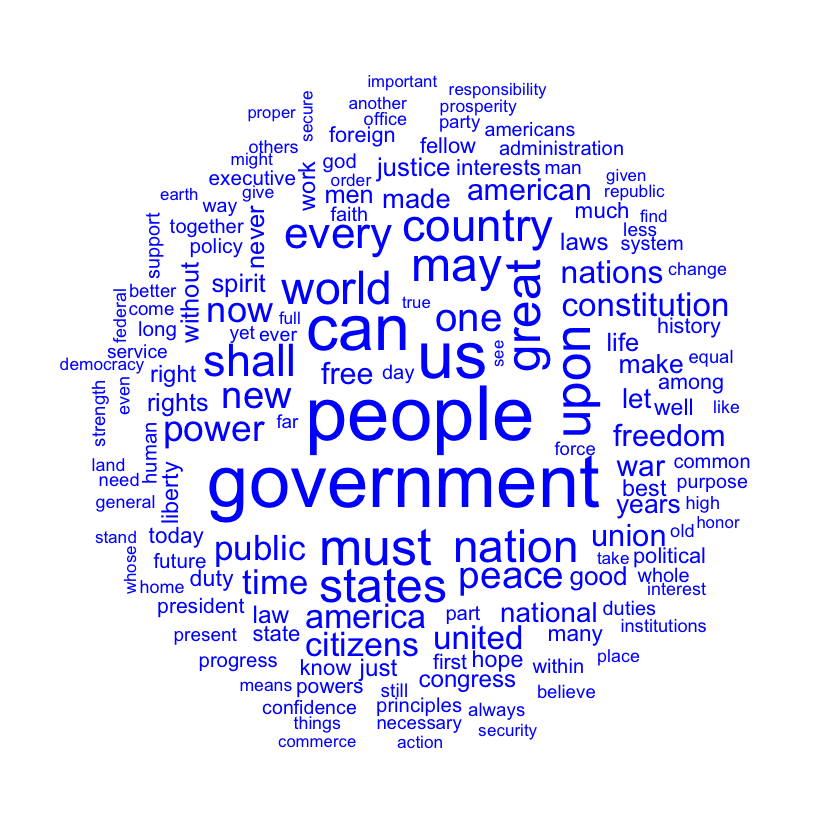

In [5]:
cloud_basic <- textplot_wordcloud(dfmat,
                   max_words = 150, color = c("blue"),
                   labelcolor = "black")

Supongamos que queremos repetir el gráfico anterior, pero por partido político. Veamos qué informción tenemos en los docvars para llevar a cabo este análisis.

In [6]:
docvars(dfmat)


Year,President,FirstName,Party
<int>,<chr>,<chr>,<fct>
1789,Washington,George,none
1793,Washington,George,none
1797,Adams,John,Federalist
1801,Jefferson,Thomas,Democratic-Republican
1805,Jefferson,Thomas,Democratic-Republican
1809,Madison,James,Democratic-Republican
1813,Madison,James,Democratic-Republican
1817,Monroe,James,Democratic-Republican
1821,Monroe,James,Democratic-Republican


Un poco incómdo para ver cuáles son las docvars y qué categorías incluye. Sin embarfo, Quanteda se integra fácilmente con las funciones de R utilizadas para explorar una base de datos:

In [7]:
names(docvars(dfmat))
levels(dfmat$Party)

[1] "Year"      "President" "FirstName" "Party"

[1] "Democratic"            "Democratic-Republican" "Federalist"           
[4] "none"                  "Republican"            "Whig"

---
## 🧠 Convenciones de nomenclatura en `quanteda`

Una de las fortalezas de `quanteda` es que utiliza una **nomenclatura consistente** para sus funciones.

En general, el nombre de la función indica **sobre qué tipo de objeto opera**, lo que facilita el aprendizaje y hace que el código sea más fácil de leer e interpretar.

---

### 📌 Convenciones más utilizadas

- `corpus_*()` → funciones para objetos `corpus`.
- `tokens_*()` → funciones para objetos `tokens`.
- `dfm_*()` → funciones para objetos `dfm` (*Document-Feature Matrix*).
- `textstat_*()` → funciones para realizar análisis estadísticos sobre texto.
- `textplot_*()` → funciones para visualizar datos textuales.

Por ejemplo:

- `dfm_trim()` modifica una DFM.
- `tokens_remove()` elimina *tokens*.
- `textplot_wordcloud()` genera una visualización.
- `textstat_keyness()` calcula una medida estadística.

---

### 💡 ¿Por qué es útil?

Una nomenclatura consistente permite:

- Identificar rápidamente el tipo de objeto sobre el que trabaja una función.
- Escribir código más legible y fácil de mantener.
- Aprender nuevas funciones de manera más intuitiva.

> 📌 **Idea clave:** En `quanteda`, el prefijo de una función suele indicar **qué tipo de objeto recibe** o **qué tipo de operación realiza**. Una vez comprendida esta lógica, resulta mucho más sencillo aprender el resto del paquete.

---

## 📂 Agrupando y seleccionando documentos: `dfm_group()` y `dfm_subset()`

Con frecuencia es necesario **agrupar** documentos según alguna característica común y, posteriormente, **seleccionar** sólo algunos de esos grupos para el análisis.

Para ello, `quanteda` proporciona dos funciones complementarias:

- **`dfm_group()`**: agrupa los documentos de una **Document-Feature Matrix (DFM)** según una **variable del documento** (*docvar*), como el presidente, el partido político, el año o cualquier otra categoría. Las frecuencias de las *features* se agregan dentro de cada grupo, generando una nueva DFM.

- **`dfm_subset()`**: permite seleccionar un subconjunto de documentos (o de grupos previamente creados con `dfm_group()`) utilizando condiciones sobre las **docvars**.

---

### 🎯 ¿Por qué utilizarlas juntas?

Es habitual combinar ambas funciones en un mismo flujo de trabajo.

Por ejemplo, primero se pueden agrupar los discursos por **partido político** y luego conservar únicamente los partidos de interés para realizar comparaciones posteriores.

> 📌 **Idea clave:** `dfm_group()` **agrega documentos** según una *docvar*, mientras que `dfm_subset()` **selecciona** únicamente aquellos documentos o grupos que cumplen una condición determinada.

In [8]:
dfmat_party <- dfmat |> dfm_group(groups = Party) |> 
                   dfm_subset(Party == "Republican" | Party == "Democratic" | Party == "Whig")
dfmat_party

Document-feature matrix of: 3 documents, 9,435 features (50.07% sparse) and 1 docvar.
            features
docs         fellow-citizens senate house representatives among vicissitudes
  Democratic               3      2     4               3    25            3
  Republican               9      5     4               6    52            0
  Whig                    13      6     1               4    10            0
            features
docs         incident life event filled
  Democratic        1   61     8      1
  Republican        2   64     2      1
  Whig              2    4     0      2
[ reached max_nfeat ... 9,425 more features ]

Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“however could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“duties could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“institutions could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“foreign could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“fellow-citizens could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“principle could not be fit on page. It will not be plotted.”
Warning message in wordcloud_comparison(x, min_size, max_size, min_count, max_words, :
“object could not

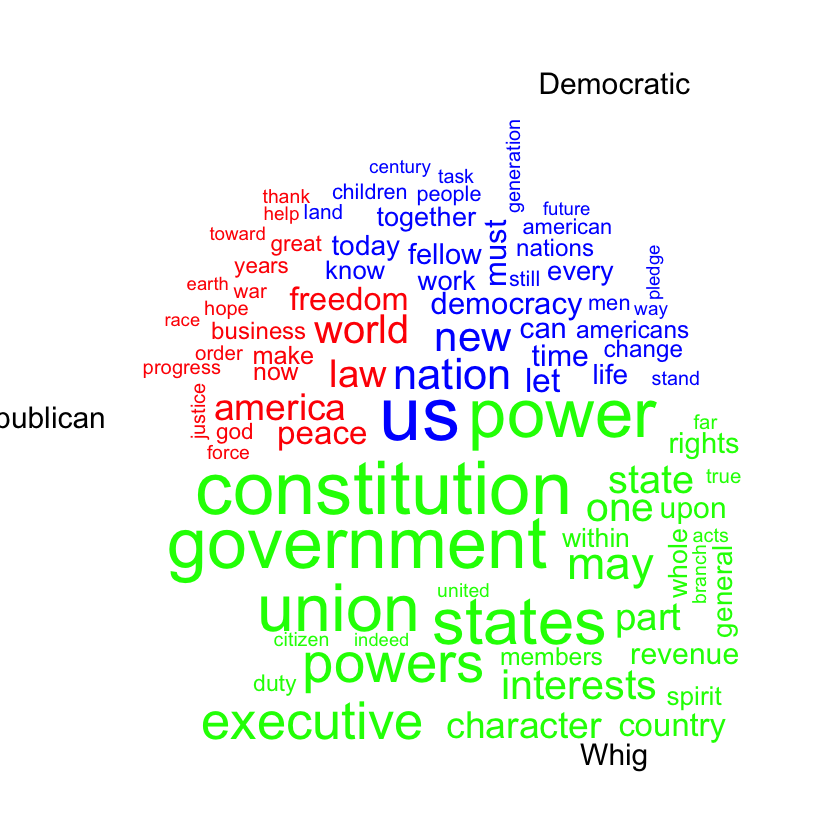

In [9]:
cloud_party <- textplot_wordcloud(dfmat_party, comparison = TRUE,
                   max_words = 150, color = c("blue", "red", "green"),
                   labelcolor = "black")

Analicemos los dos partidos más importantes:

In [10]:
dfmat_party <- dfmat |> dfm_group(groups = Party) |> 
                   dfm_subset(Party == "Republican" | Party == "Democratic")
dfmat_party

Document-feature matrix of: 2 documents, 9,435 features (38.14% sparse) and 1 docvar.
            features
docs         fellow-citizens senate house representatives among vicissitudes
  Democratic               3      2     4               3    25            3
  Republican               9      5     4               6    52            0
            features
docs         incident life event filled
  Democratic        1   61     8      1
  Republican        2   64     2      1
[ reached max_nfeat ... 9,425 more features ]

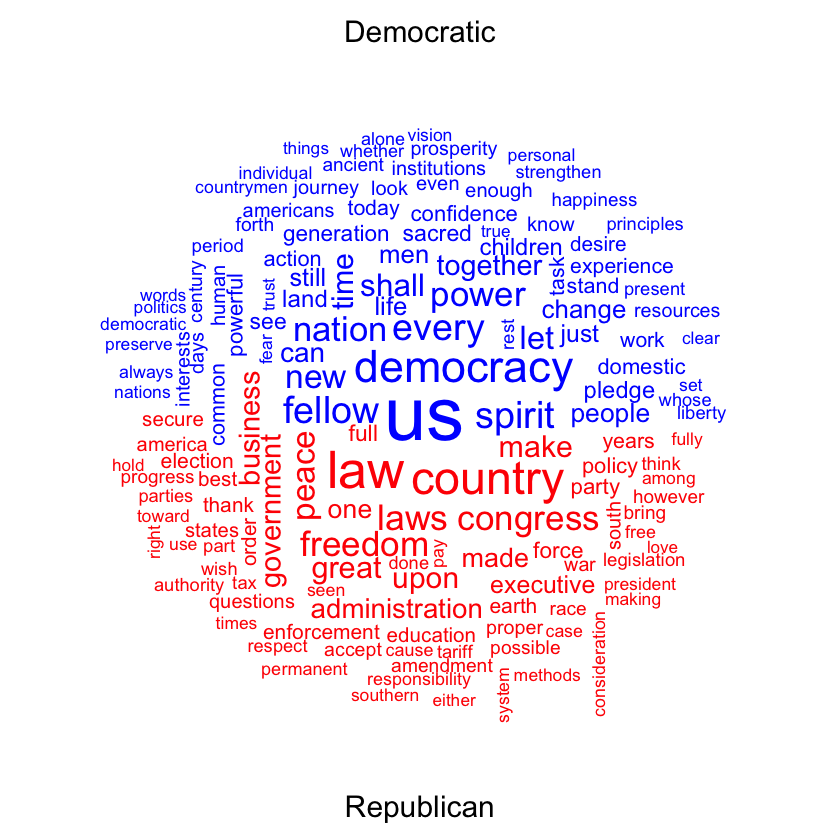

In [11]:
cloud_party <- textplot_wordcloud(dfmat_party, comparison = TRUE,
                   max_words = 150, color = c("blue", "red", "green"),
                   labelcolor = "black")

### 🗳️ Lectura política de la Nube Comparativa (Demócratas vs. Republicanos)

La nube sugiere dos énfasis retóricos distintos: el lado **demócrata** (azul) destaca un vocabulario más **aspiracional y unificador** (*democracy, peace, spirit, power, people, nation*), mientras que el lado **republicano** (rojo) destaca un vocabulario más **institucional y administrativo** (*law, government, congress, freedom, business, administration*).

> ⚠️ **Pero ojo:** esta lectura es solo exploratoria. La nube agrupa ~200 años de discursos por partido, mezclando épocas muy distintas y un número desigual de discursos/tokens por grupo — la diferencia observada podría reflejar más el **cambio histórico del lenguaje político** que un estilo partidista estable. Además, al ser frecuencia bruta, no hay ninguna prueba de que estas diferencias sean estadísticamente significativas.

📌 **Próximo paso:** usar `textstat_keyness()` para contrastar formalmente qué palabras están sobre-representadas en un partido respecto al otro, controlando por tamaño del corpus.


---
---
# II. Estadística Descriptiva Básica
---


## 📋 `summary()`

La función `summary()` proporciona un **resumen descriptivo** de un objeto. En el caso de un **corpus** de `quanteda`, entrega información general sobre su estructura y contenido.

Entre los elementos más relevantes se encuentran:

- Número de documentos.
- Número total de *tokens*.
- Número de *types* (palabras distintas).
- Información sobre las **docvars** (metadatos asociados a los documentos).

Esta función constituye una de las primeras herramientas de **exploración del corpus**, ya que permite conocer rápidamente sus principales características antes de realizar análisis más específicos.

> 📌 **Idea clave:** Al igual que en estadística descriptiva utilizamos `summary()` para obtener una primera visión de un conjunto de datos, en NLP esta función permite obtener una visión general del corpus antes de comenzar el análisis textual.


In [14]:
summary(data_corpus_inaugural, n = 6)

,Text,Types,Tokens,Sentences,Year,President,FirstName,Party
,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<fct>
1,1789-Washington,625,1537,24,1789,Washington,George,none
2,1793-Washington,96,147,5,1793,Washington,George,none
3,1797-Adams,826,2577,37,1797,Adams,John,Federalist
4,1801-Jefferson,717,1923,43,1801,Jefferson,Thomas,Democratic-Republican
5,1805-Jefferson,804,2380,45,1805,Jefferson,Thomas,Democratic-Republican
6,1809-Madison,535,1261,21,1809,Madison,James,Democratic-Republican


In [15]:
summary(dfmat)

Length  Class   Mode 
566100    dfm     S4 

---
## 📋 Uso de `summary()` en objetos de `quanteda`

La función `summary()` es una función **genérica** de R cuyo comportamiento depende del tipo de objeto al que se aplica. En `quanteda`, el resultado varía según se trate de un `corpus`, un objeto `tokens` o una **Document-Feature Matrix (DFM)**.

---

### 📌 `summary()` aplicado a un `corpus`

Cuando se utiliza sobre un objeto `corpus`, `summary()` proporciona un resumen muy útil que incluye, como ya vimos:

- La longitud de cada documento (en número de tokens).
- Las **docvars** (metadatos asociados a los documentos), como autor, fecha, partido político u otras variables.

Por ello, constituye una excelente herramienta para realizar una primera exploración del corpus.

---

### ⚠️ `summary()` aplicado a una DFM

En cambio, cuando se aplica a una **Document-Feature Matrix (DFM)**, `summary()` no entrega un resumen descriptivo del contenido.

Por ejemplo,

```r
summary(dfmat)
```

produce simplemente:

```text
Length  Class   Mode
566100    dfm     S4
```

Este resultado describe la **estructura interna del objeto**, pero aporta muy poca información para el análisis del corpus.

Lo mismo ocurre, en general, con otros objetos de `quanteda`, como `tokens`, donde `summary()` tampoco proporciona el tipo de resumen descriptivo que normalmente se espera.

---

### ✅ Recomendación

Para explorar una DFM es preferible utilizar funciones específicas, tales como:

- `ndoc(dfm)` → número de documentos.
- `nfeat(dfm)` → número de *features*.
- `ntoken(dfm)` → número total de *tokens*.
- `topfeatures(dfm)` → *features* más frecuentes.
- `featnames(dfm)` → nombres de las *features*.
- `docvars()` → acceso a las variables asociadas a los documentos.

> 📌 **Idea clave:** En `quanteda`, muchas funciones genéricas de R, como `summary()`, se comportan de manera diferente según el tipo de objeto. Antes de utilizarlas, conviene conocer qué información proporcionan para cada clase (`corpus`, `tokens`, `dfm`, etc.).

In [16]:
dim(dfmat)
ndoc(dfmat)
topfeatures(dfmat, 10)

[1]   60 9435

[1] 60

people government         us        can       must       upon      great 
       592        575        507        489        377        371        354 
       may     states      world 
       343        343        329

**ntype()** y **ntoken()** funcionan bien con los dfms. Estas funciones pueden aplicarse a un  dfm sin ningún otro argumento para ver el número de types o tokens por documento.

In [17]:
print(ntype(dfmat))

1789-Washington 1793-Washington      1797-Adams  1801-Jefferson  1805-Jefferson 
            509              58             700             593             680 
   1809-Madison    1813-Madison     1817-Monroe     1821-Monroe      1825-Adams 
            438             441             884            1100             872 
   1829-Jackson    1833-Jackson   1837-VanBuren   1841-Harrison       1845-Polk 
            433             393            1151            1699            1162 
    1849-Taylor     1853-Pierce   1857-Buchanan    1861-Lincoln    1865-Lincoln 
            413            1017             802             903             263 
     1869-Grant      1873-Grant      1877-Hayes   1881-Garfield  1885-Cleveland 
            391             440             716             884             568 
  1889-Harrison  1893-Cleveland   1897-McKinley   1901-McKinley  1905-Roosevelt 
           1199             716            1096             727             310 
      1909-Taft     1913-Wil

In [18]:
print(ntoken(dfmat))

1789-Washington 1793-Washington      1797-Adams  1801-Jefferson  1805-Jefferson 
            652              62            1070             813            1011 
   1809-Madison    1813-Madison     1817-Monroe     1821-Monroe      1825-Adams 
            526             546            1561            2023            1365 
   1829-Jackson    1833-Jackson   1837-VanBuren   1841-Harrison       1845-Polk 
            532             549            1891            3796            2264 
    1849-Taylor     1853-Pierce   1857-Buchanan    1861-Lincoln    1865-Lincoln 
            525            1584            1361            1646             339 
     1869-Grant      1873-Grant      1877-Hayes   1881-Garfield  1885-Cleveland 
            542             615            1197            1444             805 
  1889-Harrison  1893-Cleveland   1897-McKinley   1901-McKinley  1905-Roosevelt 
           2094             993            1936            1073             447 
      1909-Taft     1913-Wil

¿Y si queremos obtener información respecto de un documento en particular?

In [19]:
print(ntype(dfmat)[1])
print(ntoken(dfmat)[1])

1789-Washington 
            509 
1789-Washington 
            652 


### 📏 `ntype()` y `ntoken()` en Quanteda

Las funciones `ntype()` y `ntoken()` permiten obtener:

- `ntype()`: el número de **tipos** (palabras únicas) en cada documento.
- `ntoken()`: el número total de **tokens** (palabras incluyendo repeticiones) en cada documento.

---

### 📌 ¿Qué devuelve cada función?

Ambas funciones devuelven un **vector de enteros nombrado** (`named integer vector`), donde:

- Los **valores** son los conteos por documento.
- Los **nombres** de los elementos corresponden a los **nombres de los documentos** (`docnames(dfm)`).

Esto permite acceder directamente a los conteos de un documento específico, tal como lo acabamos de hacer.




---

### ✅ ¿Por qué esto funciona?

Como el resultado es un vector con nombres, se puede acceder a elementos específicos usando directamente el nombre del documento:

```r
ntoken(dfmat)["1789-Washington"]


In [37]:
ntoken(dfmat)["1789-Washington"]

1789-Washington 
            652

---
## **textstat_frequency()**

El comando **textstat_frequency()** puede utilizarse para hacer lo mismo que el comando **topfeatures()**, pero con información adicional, como por ejemplo, el rango de las características o su frecuencia en el corpus.

In [38]:
print(topfeatures(dfmat))

    people government         us        can       must       upon      great 
       592        575        507        489        377        371        354 
       may     states      world 
       343        343        329 


In [42]:
print(head(textstat_frequency(dfmat), n = 10))

      feature frequency rank docfreq group
1      people       592    1      58   all
2  government       575    2      53   all
3          us       507    3      57   all
4         can       489    4      57   all
5        must       377    5      53   all
6        upon       371    6      47   all
7       great       354    7      57   all
8         may       343    8      54   all
9      states       343    8      48   all
10      world       329   10      54   all


Esta función es también muy versátil para analizar estas estadísticas por grupos:

In [46]:
topfeatures(dfmat, n = 8, groups = President) %>%
  head(n = 3) %>%
  print()

$Adams
government     people      union       upon    country    nations     nation 
        33         27         22         21         18         18         17 
       may 
        16 

$Biden
       us   america       can       one    nation      must democracy    people 
       27        18        16        15        12        10        10         9 

$Buchanan
      states        shall constitution          may       people   government 
          22           18           17           15           13           13 
       great     question 
          11           11 



In [47]:
dfmat %>%
  head(n =5) %>%
  textstat_frequency(n = 8, groups = President) %>%
  print()

      feature frequency rank docfreq      group
1      people        20    1       1      Adams
2  government        16    2       1      Adams
3         may        13    3       1      Adams
4     nations        11    4       1      Adams
5     country         9    5       1      Adams
6         can         9    5       1      Adams
7      states         9    5       1      Adams
8      nation         9    5       1      Adams
9      public        18    1       2  Jefferson
10        may        18    1       2  Jefferson
11         us        17    3       2  Jefferson
12   citizens        15    4       2  Jefferson
13 government        15    4       2  Jefferson
14     fellow        13    6       2  Jefferson
15      shall        13    6       2  Jefferson
16      state        10    8       2  Jefferson
17        can         9    1       1 Washington
18      every         9    1       1 Washington
19 government         9    1       2 Washington
20        may         7    4       2 Was

¿Y si queremos comparar el resultado para dos presidentes en particular?

In [76]:
# Sub dividamos el dfm por presidente
dfmat_obama_trump <- dfmat[docvars(dfmat, "President") %in% c("Obama", "Trump"), ]

#Aplicamos la función textstat_frequency para obtener las palabras más frecuentes
textstat_frequency(dfmat_obama_trump, n = 8, groups = "President")


ERROR: Error: groups must have length ndoc(x)


In [77]:
# Esto si funciona:
dfmat_obama_trump <- dfmat[docvars(dfmat, "President") %in% c("Obama", "Trump"), ]
textstat_frequency(dfmat_obama_trump, n = 10, groups = docvars(dfmat_obama_trump, "President"))


,feature,frequency,rank,docfreq,group
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,us,44,1,2,Obama
2,must,25,2,2,Obama
3,can,20,3,2,Obama
4,people,18,4,2,Obama
5,nation,18,4,2,Obama
6,new,17,6,2,Obama
7,time,16,7,2,Obama
8,every,15,8,2,Obama
9,america,14,9,2,Obama


### ⚠️ Error común al usar `textstat_frequency()` con subconjuntos de un `dfm`

Al intentar obtener las palabras más frecuentes por presidente (por ejemplo, Obama y Trump), es común usar el argumento `groups = "President"` dentro de la función `textstat_frequency()`. Sin embargo, esto genera un error porque `"President"` es interpretado como un texto literal, no como una variable de agrupación.

El error que aparece es:

**"groups must have length ndoc(x)"**

Esto ocurre porque la función espera un **vector de longitud igual al número de documentos**, y no simplemente el nombre de la variable.

---

### ✅ Solución

La solución consiste en entregar explícitamente un vector que represente el grupo al que pertenece cada documento, en lugar de una cadena de texto. De esta forma, la función puede realizar la agrupación correctamente y generar el resumen de frecuencias por grupo.

---

### ✔️ Conclusión

> Para que el argumento `groups` funcione correctamente en `textstat_frequency()`, debe entregarse un vector con la misma longitud que el número de documentos en el `dfm`, no solo el nombre de la variable como texto.


----
## 🔤 Diversidad Léxica — `textstat_lexdiv()`

La **diversidad léxica** se refiere a la variedad de palabras o términos únicos utilizados en un texto o conjunto de textos. Es una medida que evalúa cuántos vocablos diferentes se emplean en comparación con el número total de palabras. Una alta diversidad léxica suele interpretarse como un indicador de **riqueza lingüística** o complejidad léxica del discurso.

---

### 📐 Enfoque en Quanteda

En `quanteda`, la diversidad léxica se calcula mediante la función `textstat_lexdiv()`, que proporciona varias métricas. La más común es la **relación tipo-token** (*type-to-token ratio*, TTR), definida como:

> **TTR = número de tipos únicos / número total de tokens**

Esta relación permite comparar textos de diferente longitud, aunque puede estar influida por el tamaño del documento (a mayor longitud, tiende a disminuir la TTR).

---

### 🧠 ¿Por qué es útil?

- Permite comparar estilos lingüísticos entre autores, partidos políticos, géneros, etc.
- Es útil en análisis de legibilidad, cohesión y variación del lenguaje.
- Ayuda a detectar redundancia o simplicidad excesiva en el uso del vocabulario.

---

> ✅ La diversidad léxica es una herramienta clave para explorar la riqueza y complejidad del lenguaje en textos escritos o transcritos.


In [78]:
tstat_ld <- textstat_lexdiv(dfmat) %>% arrange(TTR)

head(tstat_ld, n=10)

,document,TTR
,<chr>,<dbl>
1,1841-Harrison,0.4475764
2,1909-Taft,0.4924331
3,1973-Nixon,0.4947121
4,1845-Polk,0.5130358
5,1929-Hoover,0.5330603
6,1821-Monroe,0.5427861
7,1861-Lincoln,0.5475030
8,2021-Biden,0.5549692
9,1997-Clinton,0.5601770


In [79]:
tstat_ld %>%
  arrange(desc(TTR)) %>%
  head()

class(tstat_ld)
names(tstat_ld)

,document,TTR
,<chr>,<dbl>
1,1793-Washington,0.9354839
2,1809-Madison,0.8326996
3,1829-Jackson,0.8139098
4,1813-Madison,0.8076923
5,1945-Roosevelt,0.7882353
6,1849-Taylor,0.7866667


[1] "lexdiv"     "textstat"   "data.frame"

[1] "document" "TTR"


---
---


# III. Basic Plots
---

## Largo de los Discursos en el Tiempo

Recordemos qué tenemos en las docvars:

In [80]:
names(docvars(dfmat))

[1] "Year"      "President" "FirstName" "Party"

In [86]:
dfmat$Tokens <- ntoken(dfmat)
print(dfmat$Tokens)



 [1]  652   62 1070  813 1011  526  546 1561 2023 1365  532  549 1891 3796 2264
[16]  525 1584 1361 1646  339  542  615 1197 1444  805 2094  993 1936 1073  447
[31] 2580  805  672 1703 1881 1709  926  918  621  257 1150 1231  815  699  694
[46] 1028  852  595 1147 1302 1094  798 1130  784 1041 1173 1036  715 1143 1474


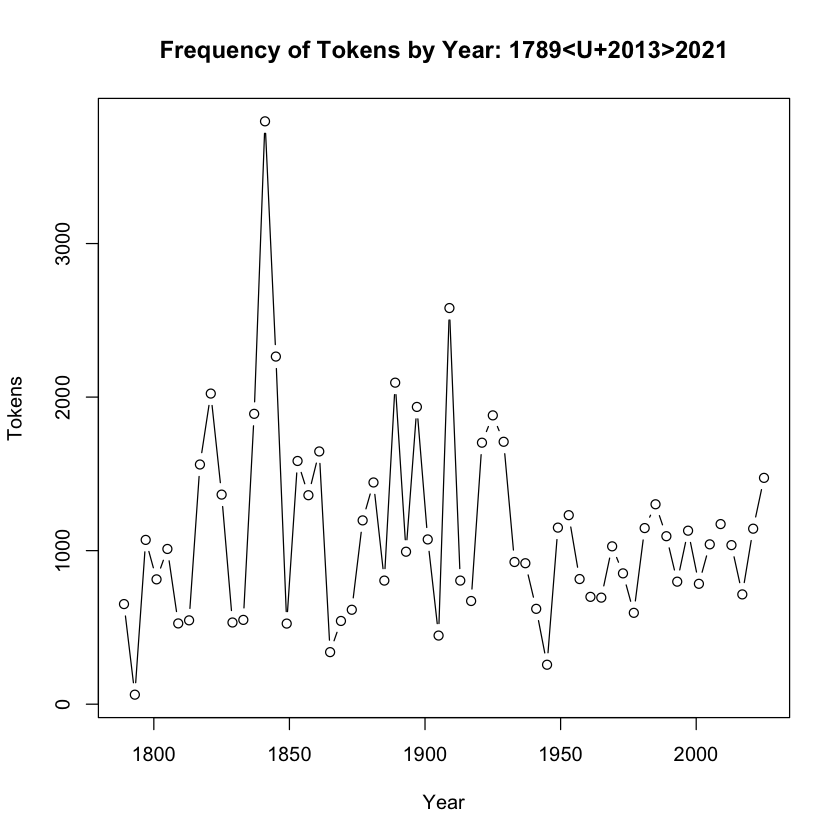

In [87]:
plot(dfmat$Year, dfmat$Tokens,
     main = "Frequency of Tokens by Year: 1789–2021", xlab = "Year", ylab = "Tokens",
     type = "b")

Mh....boomer....


In [88]:
Sys.setlocale("LC_CTYPE", "en_US.UTF-8") # For Mac users, set locale to UTF-8


[1] "en_US.UTF-8"

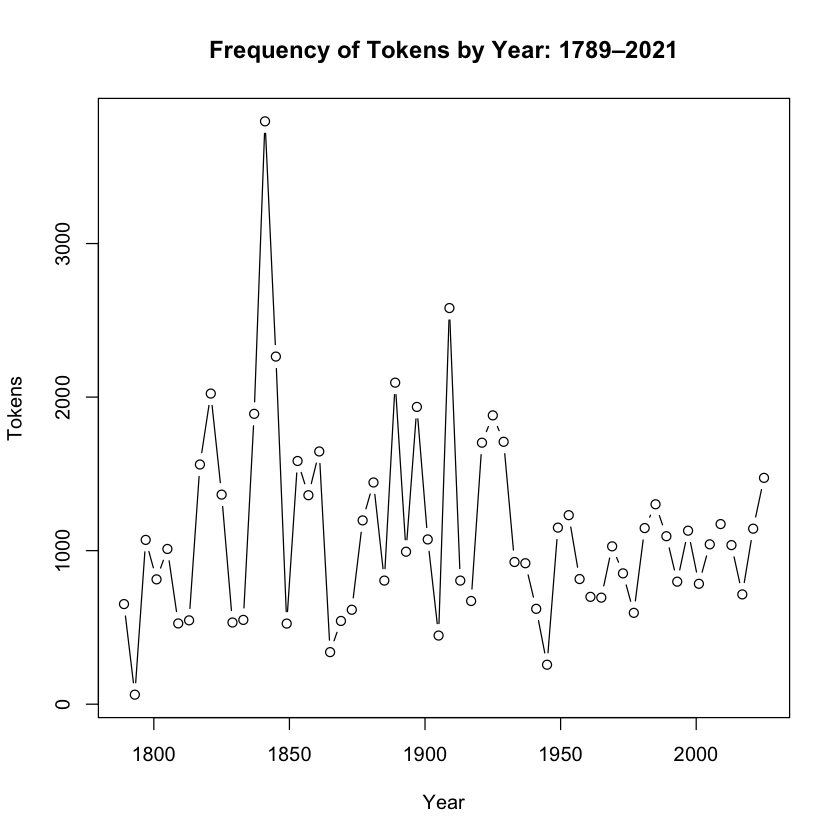

In [89]:
plot(dfmat$Year, dfmat$Tokens,
     main = "Frequency of Tokens by Year: 1789–2021", xlab = "Year", ylab = "Tokens",
     type = "b")

## Diversidad Léxica por Partidos

In [90]:
names(docvars(dfmat))


[1] "Year"      "President" "FirstName" "Party"     "Tokens"

Recuerde que TTR lo calculamos con la función *textstat_lexdiv(dfmat)* y lo guardamos en el objeto *tstat_ld*. ¿Qué tipo de objeto es este último?

In [91]:
class(tstat_ld)
head(tstat_ld)

[1] "lexdiv"     "textstat"   "data.frame"

,document,TTR
,<chr>,<dbl>
1,1841-Harrison,0.4475764
2,1909-Taft,0.4924331
3,1973-Nixon,0.4947121
4,1845-Polk,0.5130358
5,1929-Hoover,0.5330603
6,1821-Monroe,0.5427861


### 🧩 Integración de resultados: `docvars()` y outputs de `quanteda.textstats`

Es importante tener en cuenta que, aunque los objetos principales en Quanteda —como `corpus`, `tokens` y `dfm`— **no son data.frames**, el resultado de la función `docvars()` **sí lo es**. Esto permite manipular las variables asociadas a los documentos de manera flexible.

Asimismo, la mayoría de las funciones del paquete `quanteda.textstats` (como `textstat_frequency()`, `textstat_keyness()`, `textstat_lexdiv()`, etc.) devuelven resultados en forma de **data.frames**, lo que facilita su análisis, combinación o visualización posterior.

---

### 🔁 ¿Qué implica esto?

Por ejemplo, si calculamos la diversidad léxica con `textstat_lexdiv()` y almacenamos el resultado en un objeto como `tstat_ld`, podemos:

- Acceder directamente a la columna que contiene los valores de TTR (type-token ratio).
- **Asignar esos valores como una nueva variable en los `docvars()`** del `dfm`, integrando así las métricas computadas con las variables descriptivas del corpus.

Esto permite enriquecer el `dfm` con estadísticas textuales relevantes, facilitando análisis multivariados, visualizaciones o filtrado según esas métricas.

---

> ✅ La capacidad de combinar los `docvars()` del `dfm` con los resultados de `quanteda.textstats` convierte a Quanteda en una herramienta flexible y poderosa para el análisis textual estructurado.



Podemos entonces extraer directamente la variable TTR de *tstat_ld* y agregarla a las docvars de nuestro dfm:

In [92]:
dfmat$Diversity <- tstat_ld$TTR

In [93]:
names(docvars(dfmat))
class(docvars(dfmat))

[1] "Year"      "President" "FirstName" "Party"     "Tokens"    "Diversity"

[1] "data.frame"

In [94]:
docvars(dfmat)

Year,President,FirstName,Party,Tokens,Diversity
<int>,<chr>,<chr>,<fct>,<int>,<dbl>
1789,Washington,George,none,652,0.4475764
1793,Washington,George,none,62,0.4924331
1797,Adams,John,Federalist,1070,0.4947121
1801,Jefferson,Thomas,Democratic-Republican,813,0.5130358
1805,Jefferson,Thomas,Democratic-Republican,1011,0.5330603
1809,Madison,James,Democratic-Republican,526,0.5427861
1813,Madison,James,Democratic-Republican,546,0.5475030
1817,Monroe,James,Democratic-Republican,1561,0.5549692
1821,Monroe,James,Democratic-Republican,2023,0.5601770


In [95]:
class(docvars(dfmat))

[1] "data.frame"

In [96]:
library(ggplot2)

In [97]:
Diversity_by_Party<- docvars(dfmat)

In [98]:
tail(Diversity_by_Party)

,Year,President,FirstName,Party,Tokens,Diversity
,<int>,<chr>,<chr>,<fct>,<int>,<dbl>
55,2005,Bush,George W.,Republican,1041,0.7866667
56,2009,Obama,Barack,Democratic,1173,0.7882353
57,2013,Obama,Barack,Democratic,1036,0.8076923
58,2017,Trump,Donald J.,Republican,715,0.8139098
59,2021,Biden,Joseph R.,Democratic,1143,0.8326996
60,2025,Trump,Donald J.,Republican,1474,0.9354839


Nótese que solo nos ineteresan las *docvars*.

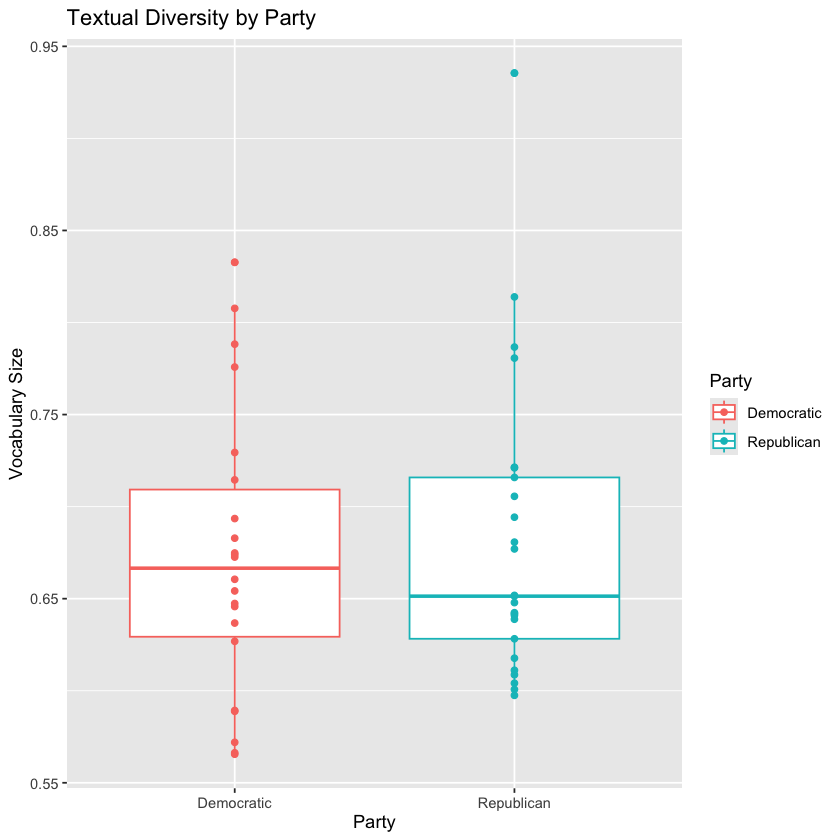

In [99]:
Diversity_by_Party %>% filter(Party=="Republican" | Party=="Democratic") %>% ggplot(aes(x = Party, y = Diversity, col=Party)) +
  geom_boxplot() +
  geom_point()+
  labs(x = "Party", y = "Vocabulary Size") +
  ggtitle("Textual Diversity by Party")

---
---
## IV. Comparando Frecuencias de Palabras al Estilo `tidytext`
---

En [*Text Mining with R*](https://www.tidytextmining.com/tidytext#the-gutenbergr-package), la sección 1.5 ("Word Frequencies") compara la frecuencia de palabras entre autores con un gráfico de dispersión en escala log-log: cada palabra se ubica según su proporción de uso en un autor (eje x) versus otro (eje y), y la línea diagonal punteada marca los casos en que ambos autores usan la palabra con igual frecuencia relativa.

Vamos a replicar esa misma idea para comparar **Obama vs. Trump**, reutilizando el `dfmat_obama_trump` que ya construimos, pero convirtiéndolo a formato *tidy* con el paquete `tidytext` en lugar de usar `textstat_frequency()`.

In [ ]:
install.packages("tidytext")
library(tidytext)

In [ ]:
# Convertimos la dfm de Obama y Trump a formato "tidy": un renglón por documento-palabra
# tidy() ya viene de tidytext y sabe leer objetos dfm de quanteda
tidy_obama_trump <- tidy(dfmat_obama_trump) %>%
  left_join(
    docvars(dfmat_obama_trump) %>%
      mutate(document = docnames(dfmat_obama_trump)) %>%
      select(document, President),
    by = "document"
  )

tidy_obama_trump

In [ ]:
# Agregamos por presidente (Obama tiene 2 discursos, Trump también) y calculamos
# la proporción de uso de cada palabra dentro del vocabulario de cada uno
frequency <- tidy_obama_trump %>%
  group_by(President, term) %>%
  summarise(n = sum(count), .groups = "drop") %>%
  group_by(President) %>%
  mutate(proportion = n / sum(n)) %>%
  select(-n) %>%
  pivot_wider(names_from = President, values_from = proportion)

frequency

In [ ]:
library(scales)

# expect a warning about rows with missing values being removed
ggplot(frequency, aes(x = Obama, y = Trump,
                      color = abs(Obama - Trump))) +
  geom_abline(color = "gray40", lty = 2) +
  geom_jitter(alpha = 0.1, size = 2.5, width = 0.3, height = 0.3) +
  geom_text(aes(label = term), check_overlap = TRUE, vjust = 1.5) +
  scale_x_log10(labels = percent_format()) +
  scale_y_log10(labels = percent_format()) +
  scale_color_gradient(limits = c(0, 0.001),
                       low = "darkslategray4", high = "gray75") +
  theme(legend.position = "none") +
  labs(x = "Obama", y = "Trump") +
  ggtitle("Comparación de Frecuencia de Palabras: Obama vs. Trump")

### 🔍 Cómo leer el gráfico

- Las palabras cercanas a la **línea diagonal punteada** se usan con frecuencia similar por ambos presidentes (p. ej. *people*, *nation*, *every*).
- Las palabras alejadas de la diagonal, hacia el eje **Trump**, son más distintivas de sus discursos (p. ej. *america*, *thank*, *country*, *american*).
- Las palabras alejadas hacia el eje **Obama** son más propias de su retórica (p. ej. *us*, *must*, *can*, *new*).
- Al ser solo 2 documentos por presidente, esta comparación es más frágil que la de Brontë/Wells/Austen (que usaba muchos más textos por autor) — conviene tratarla como exploratoria, igual que la advertencia que ya hicimos con la nube de palabras por partido.

> 📌 Esta es la misma lógica de `textstat_frequency(groups = ...)` que usamos antes con quanteda, solo que aquí construimos el data frame "a mano" con `tidytext`/`dplyr`, siguiendo el flujo de trabajo tidyverse.

---
## 🗳️ Ahora, Republicanos vs. Demócratas

Repitamos el mismo ejercicio, pero comparando los dos partidos principales en lugar de dos presidentes puntuales. Esto nos da una muestra mucho más grande (todos los discursos históricos de cada partido, no solo 2 por grupo), por lo que la comparación debería ser más estable que la de Obama vs. Trump.

Igual que antes, partimos de `dfmat` (no del `dfmat_party` agregado con `dfm_group()`, que ya perdió la información por documento) y filtramos solo los documentos de esos dos partidos.

In [90]:
# Subdividimos la dfm por partido (sin agregar documentos, a diferencia de dfmat_party)
dfmat_rep_dem <- dfmat[docvars(dfmat, "Party") %in% c("Republican", "Democratic"), ]
dfmat_rep_dem

Document-feature matrix of: 47 documents, 9,435 features (92.95% sparse) and 6 docvars.
               features
docs            fellow-citizens senate house representatives among vicissitudes
  1829-Jackson                0      0     0               0     1            1
  1833-Jackson                0      0     0               1     1            0
  1837-VanBuren               0      0     0               1     3            1
  1853-Pierce                 0      0     0               0     0            0
  1857-Buchanan               2      0     0               0     2            0
  1861-Lincoln                1      0     0               0     6            0
               features
docs            incident life event filled
  1829-Jackson         0    0     0      0
  1833-Jackson         0    1     2      0
  1837-VanBuren        0    1     1      0
  1853-Pierce          0    0     0      0
  1857-Buchanan        0    0     3      0
  1861-Lincoln         0    0     0      0
[ r

In [91]:
# Convertimos a formato tidy y unimos el partido de cada documento
tidy_rep_dem <- tidy(dfmat_rep_dem) %>%
  left_join(
    docvars(dfmat_rep_dem) %>%
      mutate(document = docnames(dfmat_rep_dem)) %>%
      select(document, Party),
    by = "document"
  )

tidy_rep_dem

document,term,count,Party
<chr>,<chr>,<dbl>,<fct>
1857-Buchanan,fellow-citizens,2,Democratic
1861-Lincoln,fellow-citizens,1,Republican
1873-Grant,fellow-citizens,1,Republican
1881-Garfield,fellow-citizens,2,Republican
1885-Cleveland,fellow-citizens,1,Democratic
1889-Harrison,fellow-citizens,1,Republican
1897-McKinley,fellow-citizens,1,Republican
1901-McKinley,fellow-citizens,2,Republican
1909-Taft,fellow-citizens,1,Republican


In [92]:
# Agregamos por partido y calculamos la proporción de uso de cada palabra
frequency_party <- tidy_rep_dem %>%
  group_by(Party, term) %>%
  summarise(n = sum(count), .groups = "drop") %>%
  group_by(Party) %>%
  mutate(proportion = n / sum(n)) %>%
  select(-n) %>%
  pivot_wider(names_from = Party, values_from = proportion)

frequency_party

term,Democratic,Republican
<chr>,<dbl>,<dbl>
"1,000",4.920776e-05,NA
100,4.920776e-05,NA
108,4.920776e-05,NA
11,4.920776e-05,NA
16,4.920776e-05,NA
1776,4.920776e-05,6.521668e-05
1787,9.841551e-05,6.521668e-05
1789,1.476233e-04,3.260834e-05
1850,4.920776e-05,NA


Warning message:
“Removed 4911 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4911 rows containing missing values or values outside the scale range
(`geom_text()`).”


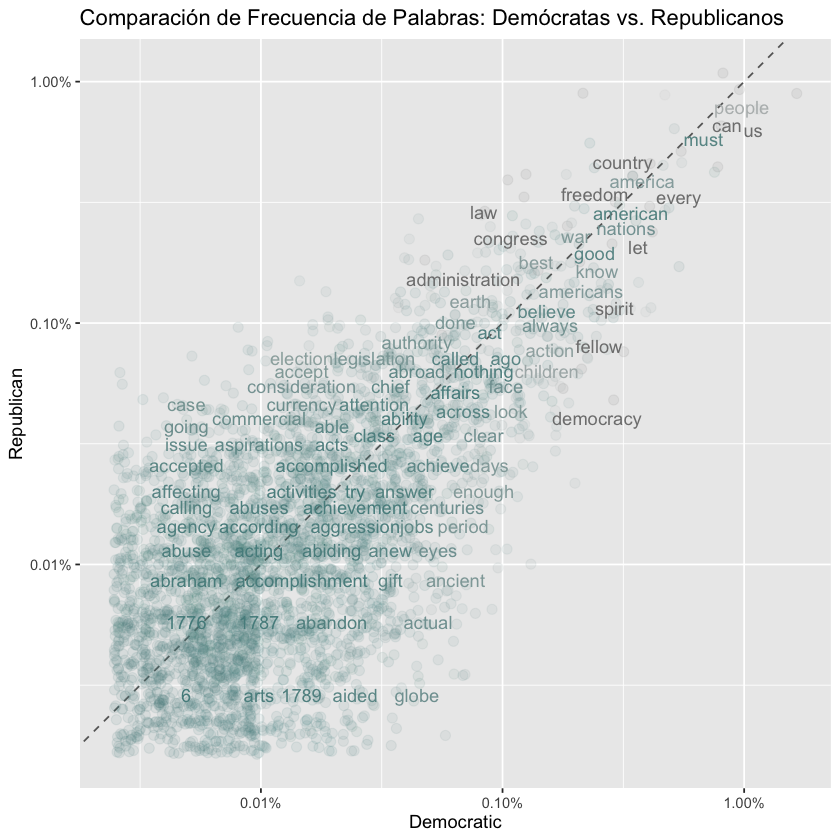

In [93]:
# expect a warning about rows with missing values being removed
ggplot(frequency_party, aes(x = Democratic, y = Republican,
                            color = abs(Democratic - Republican))) +
  geom_abline(color = "gray40", lty = 2) +
  geom_jitter(alpha = 0.1, size = 2.5, width = 0.3, height = 0.3) +
  geom_text(aes(label = term), check_overlap = TRUE, vjust = 1.5) +
  scale_x_log10(labels = percent_format()) +
  scale_y_log10(labels = percent_format()) +
  scale_color_gradient(limits = c(0, 0.001),
                       low = "darkslategray4", high = "gray75") +
  theme(legend.position = "none") +
  labs(x = "Democratic", y = "Republican") +
  ggtitle("Comparación de Frecuencia de Palabras: Demócratas vs. Republicanos")

### 🔍 Cómo leer el gráfico

- Con muchos más discursos por grupo (todos los presidentes históricos de cada partido), la nube de puntos debería verse más "llena" y las palabras más alejadas de la diagonal son candidatas más confiables a vocabulario distintivo de partido.
- Aun así, recuerda la advertencia de la sección de word clouds: esto mezcla ~200 años de discursos por partido, así que las diferencias observadas pueden reflejar **cambio histórico del lenguaje** tanto como estilo partidista. Para una comparación más rigurosa (controlando tamaño de corpus y significancia estadística), el siguiente paso natural es `textstat_keyness()`.